# Figure 9 — Effect of gas pressure under different deformation modes

This notebook evaluates the effect of gas pressure on the homogenized permeability under uniaxial stretch, volumetric deformation, and simple shear for a representative porous microstructure.

---

**Authors**

Haotian XIAO
Martin GENET

École Polytechnique, Palaiseau, France


## Imports

In [1]:
from pathlib import Path
import math
import sys

import dolfin
import myPythonLibrary as mypy
import dolfin_mech as dmech

## Project paths

In [2]:
def find_project_dir():
    current_dir = Path.cwd().resolve()

    for candidate in (current_dir, *current_dir.parents):
        if (
            (candidate / "demos").is_dir()
            and (candidate / "src").is_dir()
            and (candidate / "environment.yml").is_file()
        ):
            return candidate

    raise RuntimeError("Could not locate the project directory.")


PROJECT_DIR = find_project_dir()
SRC_DIR = PROJECT_DIR / "src"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
RESULTS_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/results


## Gas-loading function

In [3]:
def run_figure9_gas_loading(
    res_folder,
    r0,
    pg_list=(0.0, 0.2),
    mode_list=("stretch-x", "volumic", "shear"),
    probe_list=("gx", "gy"),
    perform_tests=0,
):
    res_folder = Path(res_folder)
    res_folder.mkdir(parents=True, exist_ok=True)

    test = mypy.Test(
        res_folder=str(res_folder),
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    material_parameters = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1.0,
        "eta": 1e-5,
    }

    dim = 2
    bcs = "pbc"
    n_steps = 2

    U_stretch_fin = 0.3
    U_vol_fin = 0.3
    beta_shear = 0.3

    valid_modes = ("stretch-x", "volumic", "shear")
    valid_probes = ("gx", "gy")

    for mode in mode_list:
        if mode not in valid_modes:
            raise ValueError(
                "mode must be 'stretch-x', 'volumic', or 'shear'"
            )

    for probe in probe_list:
        if probe not in valid_probes:
            raise ValueError("probe must be 'gx' or 'gy'")

    print("res_folder =", res_folder)
    print("r0 =", r0)
    print("pg_list =", pg_list)
    print("mode_list =", mode_list)
    print("probe_list =", probe_list)
    print("dim =", dim)
    print("bcs =", bcs)

    def format_float_for_filename(value):
        return f"{value:.6g}"

    def run_one_probe(mode, pg, probe):
        if probe == "gx":
            gx_ini_lst = [0.0, 0.01]
            gx_fin_lst = [0.01, 0.01]
            gy_ini_lst = [0.0, 0.0]
            gy_fin_lst = [0.0, 0.0]

        elif probe == "gy":
            gx_ini_lst = [0.0, 0.0]
            gx_fin_lst = [0.0, 0.0]
            gy_ini_lst = [0.0, 0.01]
            gy_fin_lst = [0.01, 0.01]

        r0_str = str(r0)
        pg_str = str(pg)

        res_basename = (
            f"Fig9-{mode}-r0={r0_str}-pf={pg_str}-{probe}"
        )
        result_basename = res_folder / res_basename
        mesh_filebasename = res_folder / f"mesh-r0={r0_str}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][f"sigma_bar_{i}{j}"] = 0.0

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        if mode == "stretch-x":
            load_params["solid"]["U_bar_00_lst"] = [
                0.0,
                U_stretch_fin,
            ]

        elif mode == "volumic":
            load_params["solid"]["U_bar_00_lst"] = [
                0.0,
                U_vol_fin,
            ]
            load_params["solid"]["U_bar_11_lst"] = [
                0.0,
                U_vol_fin,
            ]

        elif mode == "shear":
            load_params["solid"]["U_bar_00_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_01_lst"] = [
                0.0,
                beta_shear,
            ]
            load_params["solid"]["U_bar_10_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_11_lst"] = [0.0, 0.0]

        load_params["air"]["pf"] = pg

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3.0) / 2.0,
                "xmax": 1.0,
                "ymax": math.sqrt(3.0) / 2.0,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": str(mesh_filebasename),
            },
            mat_params={
                "skel": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs=bcs,
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2, 1e-1],
                "dt_ini_lst": [1e-3, 1e-3],
                "dt_min_lst": [1e-4, 1e-4],
                "dt_max_lst": [5e-3, 5e-3],
            },
            load_params=load_params,
            res_basename=str(result_basename),
            verbose=0,
        )

        test.test(res_basename)

    for mode in mode_list:
        for pg in pg_list:
            print()
            print("========================================")
            print(
                f"Physical case: mode={mode}, "
                f"pg={pg}, r0={r0}"
            )
            print("========================================")

            for probe in probe_list:
                print(f"Running probe={probe}")

                run_one_probe(
                    mode=mode,
                    pg=pg,
                    probe=probe,
                )

    return res_folder


## Simulation parameters

In [4]:
r0 = 0.41
pg_list = (0.0, 0.2)
mode_list = ("stretch-x", "volumic", "shear")
probe_list = ("gx", "gy")

res_folder = RESULTS_DIR / "Figure9_gas_loading"

## Numerical simulations

In [5]:
res_folder = run_figure9_gas_loading(
    res_folder=res_folder,
    r0=r0,
    pg_list=pg_list,
    mode_list=mode_list,
    probe_list=probe_list,
)

print("Results saved in:", res_folder)

res_folder = /Users/xiao/PhD/Project_MicroPoroFlow/results/Figure9_gas_loading
r0 = 0.41
pg_list = (0.0, 0.2)
mode_list = ('stretch-x', 'volumic', 'shear')
probe_list = ('gx', 'gy')
dim = 2
bcs = pbc

Physical case: mode=stretch-x, pg=0.0, r0=0.41
Running probe=gx
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 1

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Don

## Post-processing

In [6]:
from Plot_Microporoflow import plot_gas_pressure_loading_summary


def build_figure9(
    res_folder,
    r0,
    pg_list,
):
    figures_folder = RESULTS_DIR / "figures"
    figures_folder.mkdir(parents=True, exist_ok=True)

    figure_path = figures_folder / "Figure9_pg_compare.pdf"

    plot_gas_pressure_loading_summary(
        res_folder=str(res_folder),
        res_basename_prefix="Fig9",
        r0=r0,
        pf_list=pg_list,
        save_name=str(figure_path),
        show_plot=True,
    )

    return figure_path


2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-26 10:25:13.852 ( 293.357s) [          812981]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x30a20e460): Unsupported cell type: 56 Sett

## Figure generation

/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1648: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = warped.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1778: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf0 = mesh0.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1780: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to

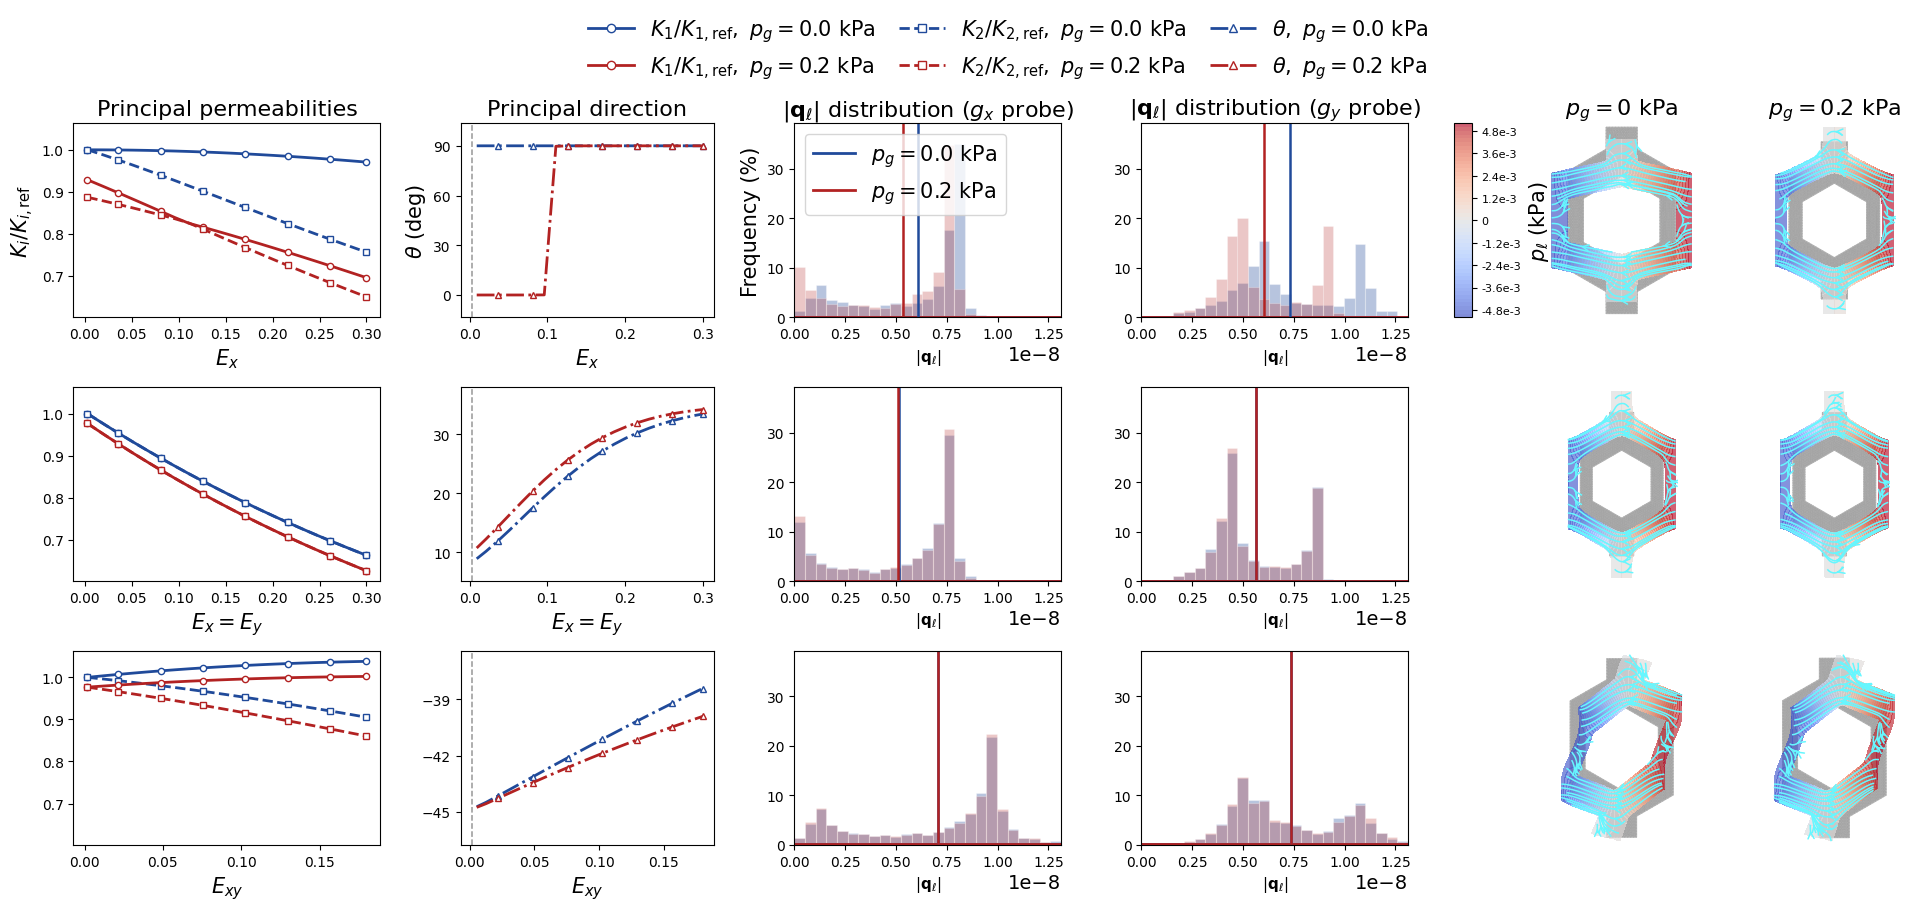

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure9_pg_compare.pdf
Figure saved in: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure9_pg_compare.pdf


In [7]:
figure_path = build_figure9(
    res_folder=res_folder,
    r0=r0,
    pg_list=pg_list,
)

print("Figure saved in:", figure_path)